# LIME De-lowlight Enhancement Results
This notebook visualizes the results of LIME filter optimization for low-light image enhancement on the LOL dataset.

We compare 4 configurations:
1. **Raw low-light**: The original low-light input.
2. **LIME-default**: The default parameters.
3. **LIME-config1-SSIM**: Optimized on LOL val split pairs to maximize SSIM.
4. **LIME-config2-BRISQUE**: Optimized on LOL val split low-light images to minimize BRISQUE.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

# Load metrics
fr_metrics_path = "../../results/delowlight/metrics/lime_full_reference_metrics.csv"
nr_metrics_path = "../../results/delowlight/metrics/lime_no_reference_metrics.csv"

if Path(fr_metrics_path).exists() and Path(nr_metrics_path).exists():
    fr_df = pd.read_csv(fr_metrics_path)
    nr_df = pd.read_csv(nr_metrics_path)
    print("Full-Reference Metrics (Evaluated with Ground Truth):")
    display(fr_df)
    print("\nNo-Reference Metrics (Evaluated on Enhanced Image only):")
    display(nr_df)
else:
    print("Metrics not found. Please run eval_all_configs.py first.")


Full-Reference Metrics (Evaluated with Ground Truth):


,Method,PSNR,SSIM,MS-SSIM,LPIPS,MAE,MSE
0,Raw low-light,7.773328,0.191405,0.191405,0.559585,99.798671,12613.619914
1,LIME-default,16.997197,0.500790,0.500790,0.365638,34.353205,1895.728391
2,LIME-config1-LOL-SSIM,19.104902,0.731407,0.731407,0.260391,29.015845,1479.461395
3,LIME-config2-LOL-BRISQUE,11.382389,0.487372,0.487372,0.336993,70.447914,6445.779789



No-Reference Metrics (Evaluated on Enhanced Image only):


,Method,BRISQUE,NIQE,PIQE,Entropy
0,Raw low-light,12.613489,6.749293,23.085796,4.761620
1,LIME-default,33.810315,8.075044,44.512210,6.916092
2,LIME-config1-LOL-SSIM,22.930904,6.455917,50.705541,6.734297
3,LIME-config2-LOL-BRISQUE,12.279537,6.594731,39.201444,6.143018


## Visual Comparisons
We display some visual comparisons below.


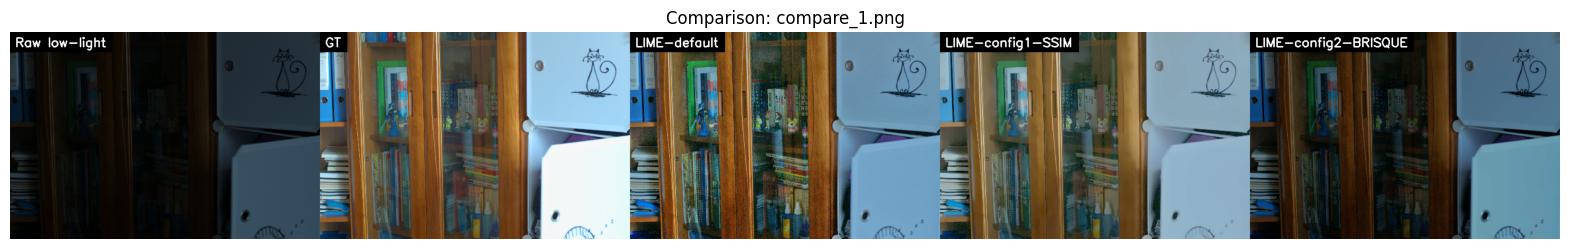

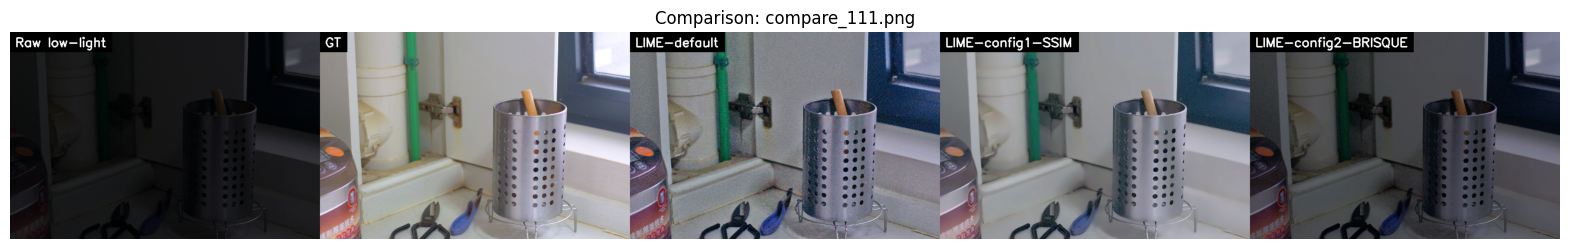

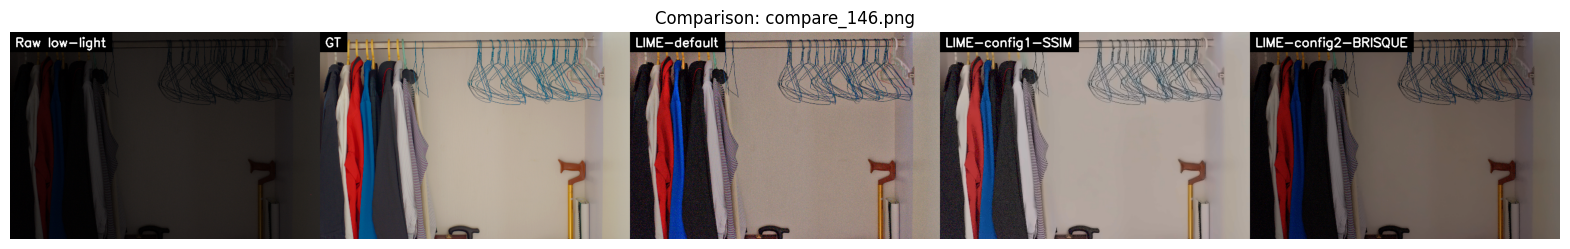

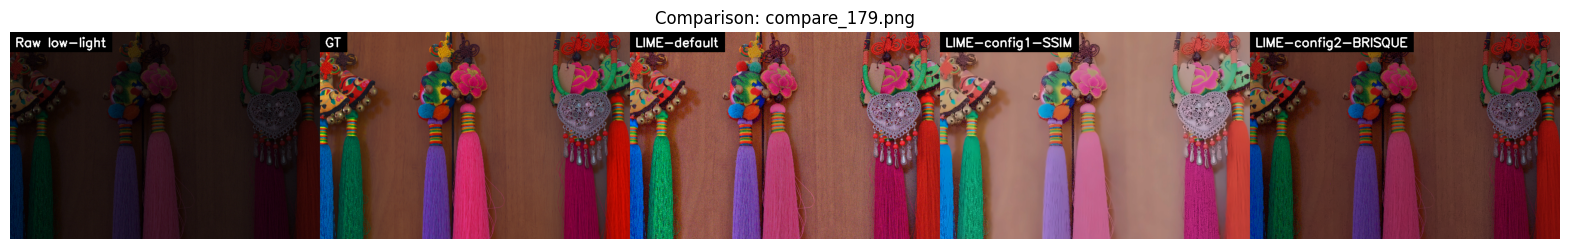

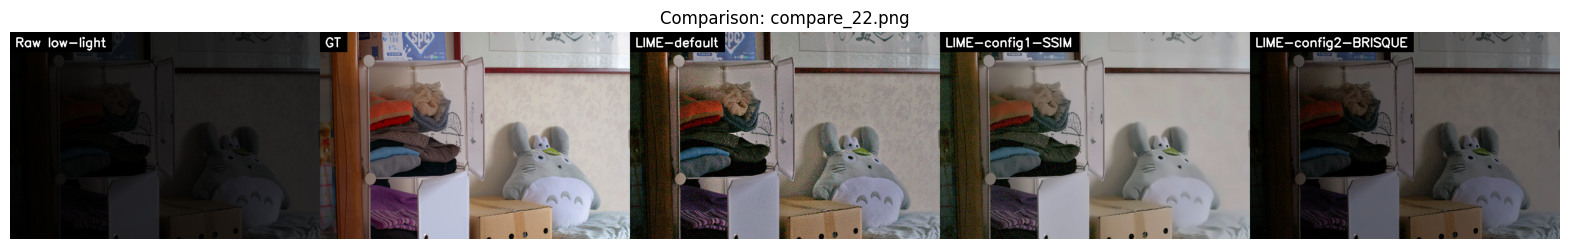

In [2]:
def show_comparison():
    fig_dir = Path("../../results/delowlight/figures/visual_comparison")
    if not fig_dir.exists():
        print("Figures directory not found.")
        return
        
    images = list(fig_dir.glob("compare_*.png"))
    # Show first 5 examples
    for img_path in images[:5]:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(20, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Comparison: {img_path.name}")
        plt.show()

show_comparison()
